# PaSCient: supervised sample-level representations

[PaSCient](https://github.com/genentech/pascient) ([Rauer et al., 2024](https://arxiv.org/abs/2404.14413)) is a supervised deep learning method that learns patient-level representations from single-cell data. It uses a gene-to-cell encoder, attention-based cell-to-patient aggregation, and a patient encoder to produce fixed-size sample embeddings.

This notebook demonstrates how to use PaSCient through `patpy` on the COMBAT dataset.

## Setup

In [1]:
import pandas as pd
import scanpy as sc
import patpy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [2]:
patpy.__version__

'0.14.0'

## Load and prepare data

We use the COMBAT dataset ([COMBAT Consortium, 2022](https://doi.org/10.1016/j.cell.2022.01.012)), available on [Kaggle](https://www.kaggle.com/datasets/vshitov/combat-covid-19-single-cell).

In [3]:
ADATA_PATH = "/home/icb/vladimir.shitov/projects/vladimir.shitov/2023_05_patient_representation_benchmark/reproducibility/pat_rep_benchmark/data/combat/combat_processed.h5ad"

In [4]:
adata = sc.read_h5ad(ADATA_PATH)
adata

AnnData object with n_obs × n_vars = 783677 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

In [5]:
sample_id_col = "scRNASeq_sample_ID"
cell_type_key = "cell_type"
samples_metadata_cols = ["Source", "Outcome", "Death28", "Institute", "Pool_ID", "binary_condition"]

In [6]:
adata.obs.rename(columns={"Annotation_major_subset": cell_type_key}, inplace=True)

In [7]:
adata = adata[~adata.obs["Source"].isin(["Sepsis", "Flu"])]
adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int)
adata.obs["binary_condition"].value_counts()

/localscratch/vladimir.shitov/ipykernel_540455/1289119485.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int)


binary_condition
1    524530
0     87204
Name: count, dtype: int64

In [8]:
metadata = adata.obs[samples_metadata_cols + [sample_id_col]].drop_duplicates()
metadata.set_index(sample_id_col, inplace=True)
metadata

,Source,Outcome,Death28,Institute,Pool_ID,binary_condition
scRNASeq_sample_ID,,,,,,
S00109-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexA,1
S00112-Ja003E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexA,1
S00005-Ja005E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexA,1
S00061-Ja003E-PBCa,COVID_SEV,4.0,0,Oxford,gPlexA,1
S00056-Ja003E-PBCa,COVID_SEV,3.0,0,Oxford,gPlexA,1
...,...,...,...,...,...,...
S00076-Ja001E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexK,1
S00072-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexK,1
S00065-Ja003E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexK,1


In [9]:
adata = patpy.pp.filter_small_samples(adata, sample_key=sample_id_col, sample_size_threshold=250)

0 samples removed: 


## Train PaSCient

Initialize PaSCient with the default hyperparameters. We train from scratch on this dataset by passing `train=True` to `prepare_anndata`.

**Important:** PaSCient expects gene expression as input. You can either provide raw counts via the `layer` parameter (with `normalize=True`, the default, which applies log-normalization automatically), or provide already log-normalized data in `adata.X` (with `normalize=False`). Providing the correct expression input is critical for good performance.

In [10]:
pascient = patpy.tl.supervised.PaSCient(
    sample_key=sample_id_col,
    label_keys=["binary_condition"],
    tasks=["classification"],
    layer="X_raw_counts",
    normalize=True,
    n_cells=1500,
    batch_size=16,
    n_epochs=10,
    device="cuda",
)

In [11]:
pascient.prepare_anndata(adata, train=True)

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'gene2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['gene2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2patient_aggregation' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2patient_aggregatio

TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 16. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 11. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

`Trainer.fit` stopped: `max_epochs=10` reached.


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


## Sample representations

Extract sample-level embeddings and evaluate using the KNN prediction score.

In [12]:
pascient_sample_reps = pascient.get_sample_representations()
pascient_sample_reps

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_502,dim_503,dim_504,dim_505,dim_506,dim_507,dim_508,dim_509,dim_510,dim_511
S00109-Ja001E-PBCa,-0.088173,-0.232828,-0.347162,-0.033108,-0.052816,1.014849,1.757772,1.460870,1.765161,0.070678,...,0.570148,1.578475,0.083600,-0.116712,-0.054835,0.872274,-0.238589,1.094642,-0.215846,-0.236827
S00112-Ja003E-PBCa,0.073960,-0.151012,-0.158590,0.154274,-0.019480,0.405957,0.984362,0.863864,0.993412,0.017086,...,0.424761,1.082420,0.015884,-0.048608,-0.041903,0.400975,-0.153430,0.659348,-0.108024,-0.163017
S00005-Ja005E-PBCa,-0.043744,-0.191478,-0.253587,0.008812,-0.047883,0.711061,1.429557,1.268280,1.402202,0.087266,...,0.511233,1.440960,0.077226,-0.092378,-0.073601,0.670419,-0.198609,0.952684,-0.160964,-0.213836
S00061-Ja003E-PBCa,-0.080665,-0.218680,-0.315627,-0.026857,-0.042968,0.917863,1.618116,1.383462,1.630699,0.063109,...,0.490312,1.494901,0.085047,-0.102030,-0.047676,0.810283,-0.221060,0.993261,-0.201030,-0.224750
S00056-Ja003E-PBCa,-0.020083,-0.151442,-0.185193,0.075588,-0.023813,0.506244,1.117671,0.922190,1.047276,0.040123,...,0.374958,1.109018,0.051262,-0.062501,-0.041099,0.474484,-0.148139,0.700781,-0.120540,-0.169912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,-0.015564,-0.154468,-0.186579,0.099015,-0.017291,0.474684,1.091443,0.905534,1.036330,0.026655,...,0.368166,1.064743,0.041877,-0.058675,-0.037863,0.438498,-0.144626,0.689773,-0.110878,-0.166872
S00072-Ja001E-PBCa,-0.090699,-0.241642,-0.352256,-0.042511,-0.044057,1.022756,1.728584,1.507140,1.827137,0.071566,...,0.557278,1.601428,0.112153,-0.118980,-0.044085,0.915939,-0.240608,1.098932,-0.226404,-0.245004
S00065-Ja003E-PBCa,-0.077453,-0.196197,-0.287879,-0.016284,-0.038115,0.840879,1.554260,1.278323,1.477396,0.059740,...,0.475478,1.376583,0.059749,-0.094819,-0.048455,0.694811,-0.198995,0.962704,-0.170082,-0.217855
S00048-Ja003E-PBCa,-0.069576,-0.197938,-0.293188,-0.007935,-0.039141,0.846573,1.535826,1.279211,1.512664,0.042303,...,0.470010,1.403785,0.066252,-0.095791,-0.047361,0.709804,-0.205099,0.952705,-0.179098,-0.212468


In [13]:
pascient_distances = pascient.calculate_distance_matrix()
patpy.tl.evaluate_representation(
    pascient_distances,
    target=metadata.loc[pascient.samples, "binary_condition"],
    task="classification"
)

{'score': np.float64(1.0),
 'metric': 'f1_macro_calibrated',
 'n_unique': 2,
 'n_observations': 101,
 'method': 'knn'}

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


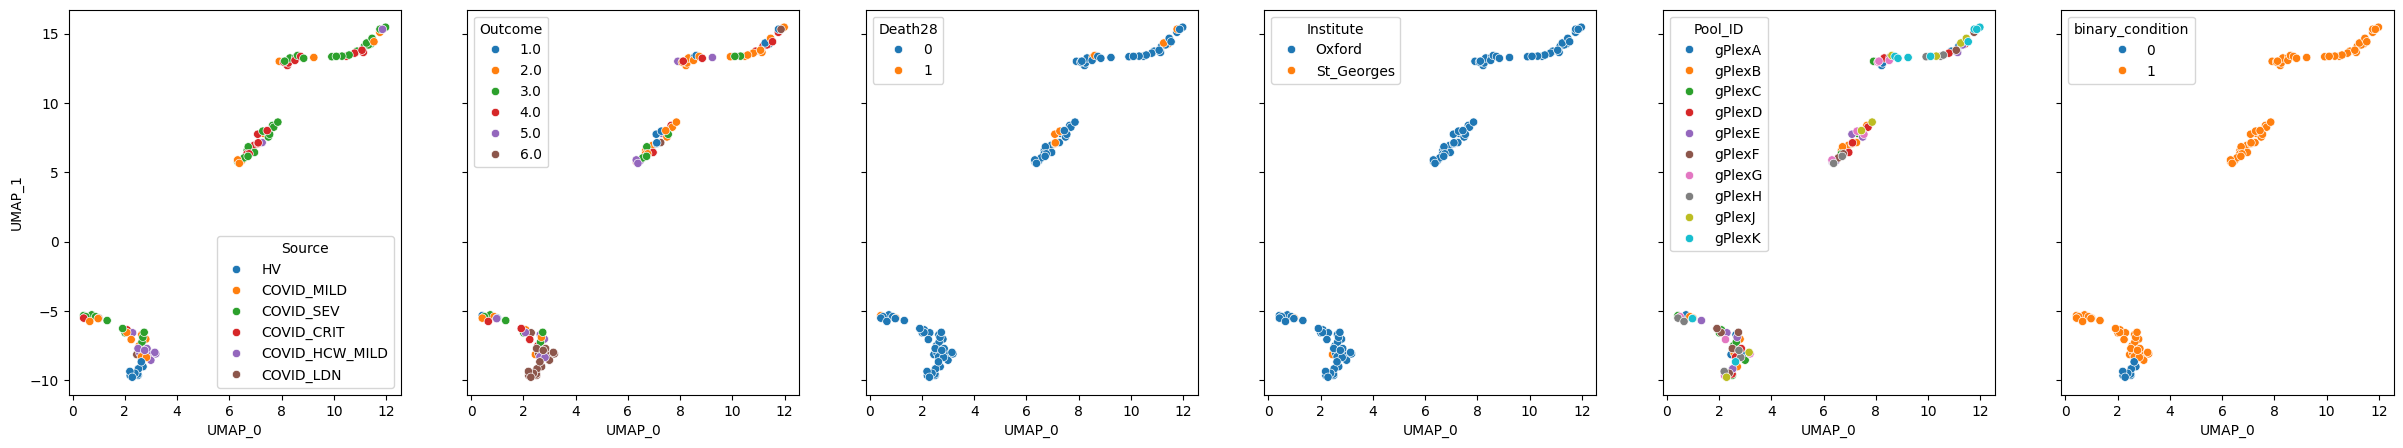

In [14]:
pascient.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

## Binary prediction

Since `binary_condition` was specified as a label during training, PaSCient can predict it directly without additional fine-tuning.

In [15]:
pascient_prediction = pascient.predict("binary_condition")
pascient_prediction

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


,prob_0,prob_1,binary_condition_pred
S00109-Ja001E-PBCa,0.000044,0.999956,1
S00112-Ja003E-PBCa,0.003916,0.996083,1
S00005-Ja005E-PBCa,0.000296,0.999704,1
S00061-Ja003E-PBCa,0.000095,0.999905,1
S00056-Ja003E-PBCa,0.002233,0.997767,1
...,...,...,...
S00076-Ja001E-PBCa,0.002672,0.997328,1
S00072-Ja001E-PBCa,0.000039,0.999961,1
S00065-Ja003E-PBCa,0.000191,0.999809,1
S00048-Ja003E-PBCa,0.000182,0.999818,1


In [16]:
y_true = metadata.loc[pascient_prediction.index, "binary_condition"]
print(classification_report(y_true, pascient_prediction["binary_condition_pred"]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        91

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



## Multiclass prediction

We can also fine-tune for the multiclass `Source` label.

In [17]:
metadata["Source"].value_counts()

Source
COVID_SEV         41
COVID_MILD        18
COVID_CRIT        18
COVID_HCW_MILD    12
HV                10
COVID_LDN          2
Name: count, dtype: int64

In [18]:
pascient.fine_tune("Source", tasks="classification")

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/_
pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

`Trainer.fit` stopped: `max_epochs=10` reached.


In [19]:
pascient_source_prediction = pascient.predict("Source")
pascient_source_prediction

,prob_COVID_CRIT,prob_COVID_HCW_MILD,prob_COVID_LDN,prob_COVID_MILD,prob_COVID_SEV,prob_HV,Source_pred
S00109-Ja001E-PBCa,0.394535,0.025477,0.025743,0.144956,0.409188,0.000101,COVID_SEV
S00112-Ja003E-PBCa,0.063328,0.267164,0.217097,0.295604,0.150487,0.006321,COVID_MILD
S00005-Ja005E-PBCa,0.880595,0.003001,0.008579,0.024722,0.083051,0.000052,COVID_CRIT
S00061-Ja003E-PBCa,0.388946,0.029524,0.029042,0.148687,0.403622,0.000178,COVID_SEV
S00056-Ja003E-PBCa,0.210393,0.132618,0.112567,0.244251,0.297248,0.002924,COVID_SEV
...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,0.125680,0.192639,0.150116,0.281483,0.246566,0.003515,COVID_MILD
S00072-Ja001E-PBCa,0.361417,0.029526,0.027950,0.170613,0.410370,0.000123,COVID_SEV
S00065-Ja003E-PBCa,0.398539,0.032703,0.032377,0.143577,0.392591,0.000213,COVID_CRIT
S00048-Ja003E-PBCa,0.378879,0.033592,0.032130,0.151074,0.404112,0.000212,COVID_SEV


In [20]:
source_true = metadata.loc[pascient_source_prediction.index, "Source"]
print(classification_report(source_true, pascient_source_prediction["Source_pred"]))

                precision    recall  f1-score   support

    COVID_CRIT       0.68      0.72      0.70        18
COVID_HCW_MILD       0.59      0.83      0.69        12
     COVID_LDN       0.00      0.00      0.00         2
    COVID_MILD       0.60      0.50      0.55        18
     COVID_SEV       0.72      0.71      0.72        41
            HV       1.00      1.00      1.00        10

      accuracy                           0.70       101
     macro avg       0.60      0.63      0.61       101
  weighted avg       0.69      0.70      0.69       101



/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


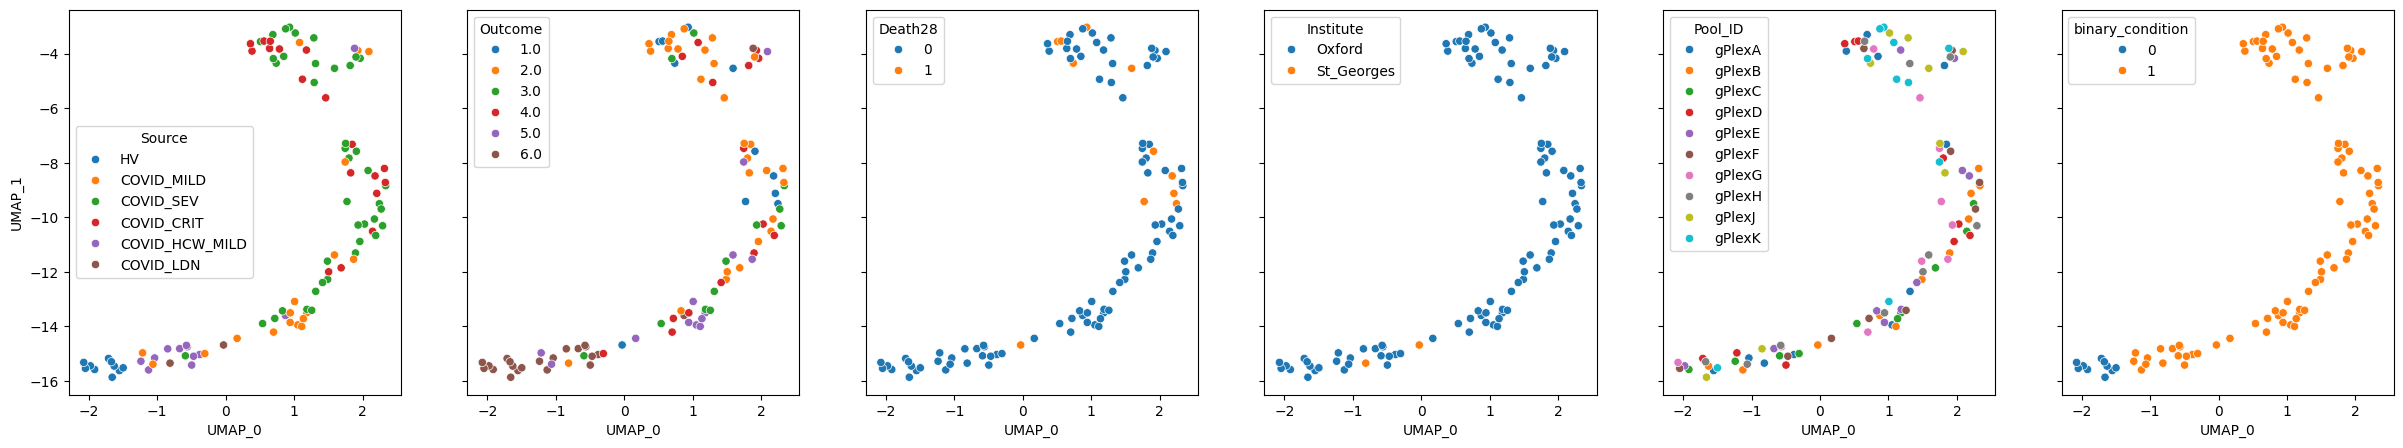

In [21]:
pascient_distances = pascient.calculate_distance_matrix()
pascient.embed("UMAP")
pascient.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

### Cell importance

PaSCient can compute per-cell importance scores to identify which cells contribute most to sample-level representations.

> **Note:** By default, `get_cell_importance()` uses Integrated Gradients (IG) from the PaSCient paper when [captum](https://captum.ai/) is installed, and falls back to cosine similarity between cell and sample embeddings otherwise.

In [22]:
cell_importance = pascient.get_cell_importance(target=1)
importance_scores = cell_importance.iloc[:, 0]
print(f"Importance scores: min={importance_scores.min():.4f}, max={importance_scores.max():.4f}, mean={importance_scores.mean():.4f}")

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


Importance scores: min=0.0000, max=0.0415, mean=0.0000


### Cell importance by disease severity and cell type

Visualize the distribution of cell importance scores. Since most scores are near zero with a long tail of important cells, we use strip plots with log-scaled y-axis for better visibility.

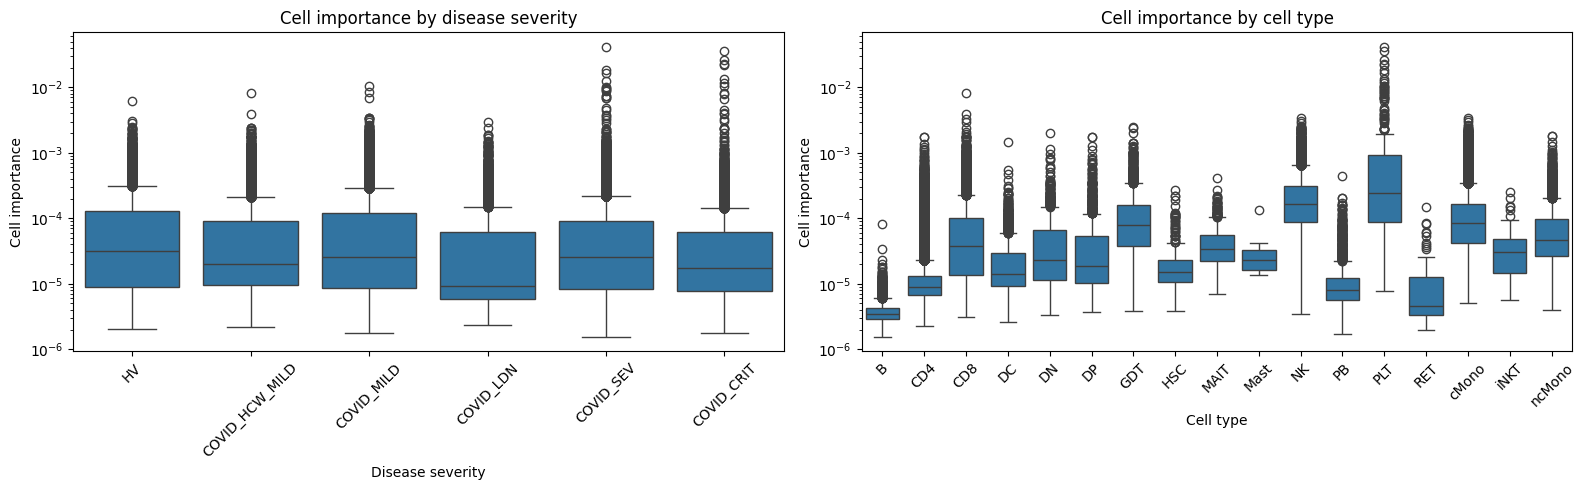

In [23]:
import seaborn as sns

# Build dataframe with importance scores and metadata
cell_imp_df = pd.DataFrame({
    "importance": importance_scores,
    "Source": adata.obs["Source"].values,
    "cell_type": adata.obs[cell_type_key].values,
}, index=adata.obs_names)

severity_order = ["HV", "COVID_HCW_MILD", "COVID_MILD", "COVID_LDN", "COVID_SEV", "COVID_CRIT"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Filter to nonzero for log-scale
nonzero = cell_imp_df[cell_imp_df["importance"] > 0]

# By disease severity
ax = axes[0]
sns.boxplot(data=nonzero, x="Source", y="importance", order=severity_order, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Disease severity")
ax.set_ylabel("Cell importance")
ax.set_title("Cell importance by disease severity")
ax.tick_params(axis="x", rotation=45)

# By cell type
ax = axes[1]
sns.boxplot(data=nonzero, x="cell_type", y="importance", ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Cell type")
ax.set_ylabel("Cell importance")
ax.set_title("Cell importance by cell type")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Summary statistics

Descriptive statistics of cell importance scores grouped by disease severity and cell type.

In [24]:
print("=== Cell importance by disease severity ===")
cell_imp_df.groupby("Source")["importance"].describe().loc[severity_order].round(6)

=== Cell importance by disease severity ===


/localscratch/vladimir.shitov/ipykernel_540455/745167923.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_imp_df.groupby("Source")["importance"].describe().loc[severity_order].round(6)


,count,mean,std,min,25%,50%,75%,max
Source,,,,,,,,
HV,87204.0,0.000018,0.000088,0.0,0.0,0.0,0.000000,0.006155
COVID_HCW_MILD,84359.0,0.000018,0.000088,0.0,0.0,0.0,0.000000,0.008232
COVID_MILD,107376.0,0.000027,0.000121,0.0,0.0,0.0,0.000003,0.010584
COVID_LDN,14832.0,0.000017,0.000093,0.0,0.0,0.0,0.000000,0.002996
COVID_SEV,230343.0,0.000021,0.000139,0.0,0.0,0.0,0.000004,0.041486
COVID_CRIT,87620.0,0.000018,0.000210,0.0,0.0,0.0,0.000007,0.035924


In [25]:
print("=== Cell importance by cell type (sorted by max) ===")
cell_imp_df.groupby("cell_type")["importance"].describe().round(6).sort_values("max", ascending=False)

=== Cell importance by cell type (sorted by max) ===


/localscratch/vladimir.shitov/ipykernel_540455/3781085762.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_imp_df.groupby("cell_type")["importance"].describe().round(6).sort_values("max", ascending=False)


,count,mean,std,min,25%,50%,75%,max
cell_type,,,,,,,,
PLT,920.0,0.000544,0.002747,0.0,0.0,0.0,0.000052,0.041486
CD8,87562.0,0.000020,0.000078,0.0,0.0,0.0,0.000000,0.008232
cMono,152220.0,0.000035,0.000105,0.0,0.0,0.0,0.000015,0.003444
NK,57648.0,0.000058,0.000161,0.0,0.0,0.0,0.000000,0.003357
GDT,7935.0,0.000033,0.000109,0.0,0.0,0.0,0.000000,0.002455
DN,3426.0,0.000015,0.000066,0.0,0.0,0.0,0.000000,0.002018
ncMono,21281.0,0.000019,0.000062,0.0,0.0,0.0,0.000000,0.001800
DP,5354.0,0.000014,0.000064,0.0,0.0,0.0,0.000000,0.001764
CD4,218353.0,0.000004,0.000017,0.0,0.0,0.0,0.000000,0.001737


In this tutorial you learned how to train PaSCient from scratch, extract sample representations, evaluate them, make binary and multiclass predictions, and compute cell importance scores with `patpy`.